In [2]:
import pandas as pd

In [29]:
df = pd.read_csv("../analysis/data_for_analysis.csv")


In [6]:
df[df["cons_alternation_past"].notna() & df["vowel_alternation_pres"].notna() & df["vowel_alternation_past"].notna()]

,form,norm,lemma,inflClass,infl,date,id,lemma_count,lemma_freq_per_1000,form_count,...,target_vowel_past,target_coda_past,is_leveled_vowel_pres,is_leveled_vowel_past,is_leveled_cons_pres,is_leveled_cons_past,vowel_alternation_pres,vowel_alternation_past,cons_alternation_pres,cons_alternation_past
0,zoh,zôch,zièhen,st2b,Ind.Past.Sg.3,1100.0,M001,522,0.202382,34,...,NaN,NaN,NaN,NaN,NaN,NaN,o ~ ie,o ~ u,NaN,χ ~ g
29,zoh,zôch,zièhen,st2b,Ind.Past.Sg.3,1150.0,M004,522,0.202382,34,...,NaN,NaN,NaN,NaN,NaN,NaN,o ~ ie,o ~ u,NaN,χ ~ g
223,irkoſ,erkôs,er-kièsen,st2b,Ind.Past.Sg.3,1160.0,M005,236,0.091499,2,...,NaN,NaN,NaN,NaN,NaN,NaN,o ~ ie,o ~ u,NaN,s ~ r
373,zoch,zôch,zièhen,st2b,Ind.Past.Sg.3,1160.0,M005,522,0.202382,110,...,NaN,NaN,NaN,NaN,NaN,NaN,o ~ ie,o ~ u,NaN,χ ~ g
499,zvgen,zugen,zièhen,st2b,(Ind).Past.Pl.3,1167.0,M008,522,0.202382,14,...,NaN,NaN,NaN,NaN,NaN,NaN,u ~ ie,u ~ o,g ~ h,g ~ χ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46638,zoch,zoch,abziehen,St,3.Sg.Prät.Ind,1392.0,t19059,95,0.362039,194,...,NaN,NaN,NaN,NaN,NaN,NaN,e ~ i,e ~ i,NaN,χ ~ g
46643,zoch,zoch,abziehen,St,3.Sg.Prät.Ind,1392.0,t19370,95,0.362039,194,...,NaN,NaN,NaN,NaN,NaN,NaN,e ~ i,e ~ i,NaN,χ ~ g
46647,zoch,zoch,abziehen,St,3.Sg.Prät.Ind,1392.0,t19576,95,0.362039,194,...,NaN,NaN,NaN,NaN,NaN,NaN,e ~ i,e ~ i,NaN,χ ~ g
46666,zoch,zoch,abziehen,St,3.Sg.Prät.Ind,1392.0,t20318,95,0.362039,194,...,NaN,NaN,NaN,NaN,NaN,NaN,e ~ i,e ~ i,NaN,χ ~ g


In [6]:
df_ziehen = df[df["lemma_id"] == 275][["form", "variety", "vowel_alternation_pres", "vowel_alternation_past", "cons_alternation_pres", "cons_alternation_past"]]

In [ ]:
for i, row in df_ziehen.iterrows():
    print(row)
    print("___"*20 + "\n")

In [30]:
# List of your target columns
target_columns = [
    "vowel_alternation_pres", 
    "vowel_alternation_past", 
    "cons_alternation_pres", 
    "cons_alternation_past"
]

for col in target_columns:
    # 1. Fill in the NAs with "no_alternation" using direct assignment
    df[col] = df[col].fillna("no_alternation")
    
    # 2. Get the frequency of each category
    counts = df[col].value_counts()
    
    # 3. Map those counts to the new column
    df[f"{col}_freq"] = df[col].map(counts)

# Quick check to see the results
print(df.head())

      lemma  lemma_std  date  log_freq      marking_type  is_bipartite  \
0  sprëchen         27  1100  1.497726  vowel_unipartite             0   
1     lâzen          4  1150  0.367627  vowel_unipartite             0   
2  sprëchen         27  1150 -3.547719  vowel_unipartite             0   
3     hèben         90  1150 -1.367187  vowel_unipartite             0   
4    fahren         89  1150 -0.164403  vowel_unipartite             0   

  element_type  has_levelled vowel_alternation_pres vowel_alternation_past  \
0        vowel             0                  a ~ e         no_alternation   
1        vowel             0                 ie ~ a         no_alternation   
2        vowel             0                  a ~ e         no_alternation   
3        vowel             0                 uo ~ e         no_alternation   
4        vowel             0                 uo ~ a         no_alternation   

  cons_alternation_pres cons_alternation_past    id         variety std_infl  \
0     

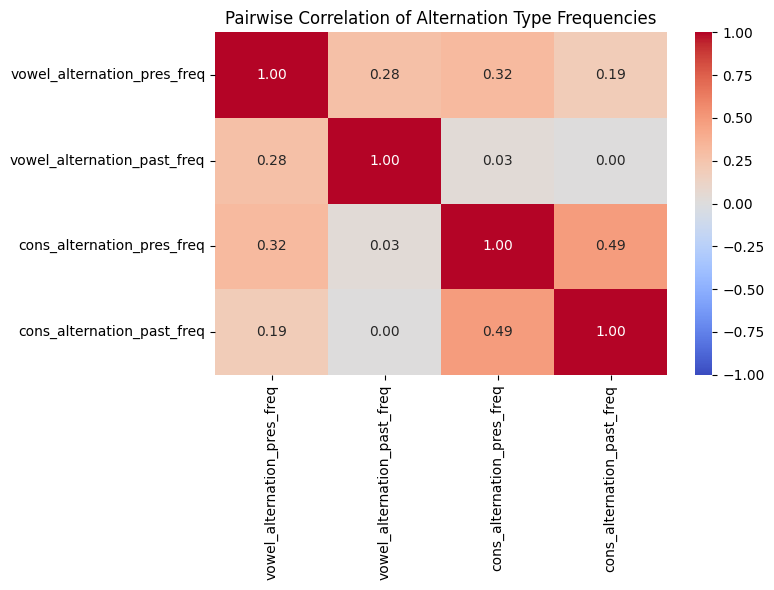

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and target_columns is already defined
freq_cols = [f"{col}_freq" for col in target_columns]

# Calculate Pearson correlation
corr_matrix = df[freq_cols].corr()

# Visualize with a heatmap for quick inspection
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Pairwise Correlation of Alternation Type Frequencies")
plt.tight_layout()
plt.show()

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF requires a constant (intercept) to be calculated correctly
X = add_constant(df[freq_cols])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Filter out the constant from the printout
print(vif_data[vif_data["Feature"] != "const"])

                       Feature       VIF
1  vowel_alternation_pres_freq  1.211236
2  vowel_alternation_past_freq  1.088074
3   cons_alternation_pres_freq  1.413054
4   cons_alternation_past_freq  1.317987


In [37]:
df.value_counts(["vowel_alternation_pres", "vowel_alternation_past"])


vowel_alternation_pres  vowel_alternation_past
a ~ e                   no_alternation            6965
ie ~ a                  no_alternation            1083
a ~ i                   a ~ u                      780
uo ~ a                  no_alternation             740
a ~ e                   a ~ u                      681
ua ~ u                  no_alternation             392
ie ~ ei                 no_alternation             346
uo ~ e                  no_alternation             333
a ~ i                   no_alternation             299
o ~ ie                  o ~ u                      216
ie ~ ou                 no_alternation             152
a ~ ie                  no_alternation             148
ie ~ uo                 no_alternation             140
u ~ e                   u ~ a                      126
ei ~ i                  ei ~ i                      93
u ~ ie                  u ~ o                       73
u ~ i                   u ~ a                       67
no_alternation    